This project replicates the HAR-RV model from Corsi (2009) and benchmarks it against a Random Forest and a shallow MLP on realized volatility forecasting. Model performance is evaluated using QLIKE loss, Mincer-Zarnowitz regressions, and Diebold-Mariano tests, with a naïve baseline as the floor.

In [13]:
#Packages  
import numpy as np
import yfinance as yf 
import pandas as pd
import statsmodels.api as sm
import statsmodels.formula.api as smf
import matplotlib.pyplot as plt
from datetime import datetime
from scipy import stats
import os
from sklearn.preprocessing import StandardScaler
from pathlib import Path



In [25]:
#Downloading the Oxford-Man Realized Volatility Dataset 
data_path=Path('data/oxfordmanrealizedvolatilityindices.csv') 
df=pd.read_csv(data_path)
sp500=df[df["Symbol"]==".SPX"].copy() #Extracting SP500 from the dataset
sp500.tail()

,Unnamed: 0,Symbol,open_time,close_price,rv5_ss,bv,rk_parzen,rk_twoscale,bv_ss,open_price,nobs,rk_th2,medrv,rv10_ss,rsv_ss,open_to_close,rv10,rsv,rv5,close_time
112698,2018-06-21 00:00:00+01:00,.SPX,93001.0,2749.71,0.000030,0.000029,0.000032,0.000030,0.000029,2769.28,23401.0,0.000029,0.000014,0.000031,0.000021,-0.007092,0.000031,0.000021,0.000030,160001.0
112699,2018-06-22 00:00:00+01:00,.SPX,93001.0,2754.69,0.000015,0.000011,0.000014,0.000017,0.000011,2760.79,23401.0,0.000016,0.000005,0.000014,0.000010,-0.002212,0.000014,0.000010,0.000015,160001.0
112700,2018-06-25 00:00:00+01:00,.SPX,93001.0,2717.06,0.000082,0.000072,0.000102,0.000059,0.000072,2742.94,23401.0,0.000058,0.000059,0.000101,0.000044,-0.009480,0.000101,0.000044,0.000082,160001.0
112701,2018-06-26 00:00:00+01:00,.SPX,93001.0,2722.97,0.000029,0.000029,0.000018,0.000031,0.000029,2722.12,23401.0,0.000031,0.000019,0.000026,0.000013,0.000312,0.000026,0.000013,0.000029,160001.0
112702,2018-06-27 00:00:00+01:00,.SPX,93001.0,2699.82,0.000074,0.000066,0.000075,0.000057,0.000066,2728.45,23401.0,0.000056,0.000045,0.000072,0.000049,-0.010549,0.000072,0.000049,0.000074,160001.0


HAR-RV Model

In [23]:
#Construct HAR-RV Components of 5 minute average, one week average, and one month average
sp500["log_rv"]=np.log(sp500["rv5"])
def rv_parts(df:pd.DataFrame)->pd.DataFrame:
    df["RV_daily"]=df["log_rv"].rolling(1).mean().shift(1)
    df["RV_weekly"]=df["log_rv"].rolling(window=5).mean().shift(1)
    df["RV_monthly"]=df["log_rv"].rolling(window=22).mean().shift(1)
    df["RV_target"]=df["log_rv"].shift(-1)
    df=df.dropna()
    return df 
sp500_rv=rv_parts(sp500)
sp500_rv.head()



,Unnamed: 0,Symbol,open_time,close_price,rv5_ss,bv,rk_parzen,rk_twoscale,bv_ss,open_price,...,open_to_close,rv10,rsv,rv5,close_time,log_rv,RV_daily,RV_weekly,RV_monthly,RV_target
108084,2000-02-03 00:00:00+00:00,.SPX,83001.0,1424.20,0.000148,0.000149,0.000173,0.000129,0.000149,1409.12,...,0.010645,0.000189,0.000054,0.000148,150001.0,-8.817660,-9.269886,-8.733457,-8.989183,-9.602678
108085,2000-02-04 00:00:00+00:00,.SPX,83009.0,1424.43,0.000068,0.000055,0.000068,0.000065,0.000055,1427.49,...,-0.002146,0.000089,0.000039,0.000068,150009.0,-9.602678,-8.817660,-8.780808,-8.986892,-9.717212
108086,2000-02-07 00:00:00+00:00,.SPX,83003.0,1424.27,0.000060,0.000061,0.000060,0.000066,0.000061,1426.02,...,-0.001228,0.000056,0.000032,0.000060,145954.0,-9.717212,-9.602678,-9.063843,-9.041410,-9.304339
108087,2000-02-08 00:00:00+00:00,.SPX,83007.0,1440.90,0.000091,0.000064,0.000122,0.000061,0.000064,1424.24,...,0.011630,0.000111,0.000019,0.000091,145955.0,-9.304339,-9.717212,-9.292691,-9.116501,-9.281690
108088,2000-02-09 00:00:00+00:00,.SPX,83024.0,1412.47,0.000093,0.000099,0.000161,0.000101,0.000099,1443.95,...,-0.022042,0.000114,0.000070,0.000093,150023.0,-9.281690,-9.304339,-9.342355,-9.132981,-9.054339


In [26]:
#Fitting the HAR-RV model 
X=sp500_rv[["RV_daily","RV_weekly","RV_monthly"]]
y=sp500_rv["RV_target"]
#Train Test Split 80/20 Train Test split 
split=int(len(sp500_rv)*.8)
X_train,X_test=X.iloc[:split],X.iloc[split:]
y_train,y_test=y.iloc[:split],y.iloc[split:]
X_train_c = sm.add_constant(X_train)
X_test_c  = sm.add_constant(X_test)

model=sm.OLS(y_train,X_train_c).fit(cov_type='HAC',cov_kwds={'maxlags':5})
HAR_pred = model.predict(X_test_c)
print(model.summary())


                            OLS Regression Results                            
Dep. Variable:              RV_target   R-squared:                       0.664
Model:                            OLS   Adj. R-squared:                  0.663
Method:                 Least Squares   F-statistic:                     1326.
Date:                Sat, 25 Apr 2026   Prob (F-statistic):               0.00
Time:                        14:50:57   Log-Likelihood:                -3448.6
No. Observations:                3694   AIC:                             6905.
Df Residuals:                    3690   BIC:                             6930.
Df Model:                           3                                         
Covariance Type:                  HAC                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.6641      0.147     -4.522      0.0

Model Evaluations: QLIKE loss, Mincer-Zarnowitz, and Diebold-Mariano

In [27]:
#QLIKE Loss
def qlike_loss(actual:pd.Series,predicted:pd.Series)->None:
    #Exponetiate out of log scale
    a=np.exp(np.array(actual))
    p=np.exp(np.array(predicted))
    return np.mean(a/p-np.log(a/p)-1)
#Creating a Naive Benchmark that uses last known value of RV to compare to HAR-RV model
naive_pred=y_test.shift(1).dropna()
y_test_naive=y_test.iloc[1:]

qlike_har=qlike_loss(y_test,HAR_pred)
qlike_naive=qlike_loss(y_test_naive,naive_pred)

print(f"QLIKE HAR: {qlike_har:.6f}")
print(f"QLIKE Naive: {qlike_naive:.6f}")
print(f"Improvement over Naive:{((qlike_naive-qlike_har)/qlike_naive)*100:.6f} ")



QLIKE HAR: 0.402441
QLIKE Naive: 0.292132
Improvement over Naive:-37.759873 


THe HAR-RV underperforms the naive implementation on the QLIKE loss likely due to slow mean-reversion
of smoothed components in low-vol regimes.

In [28]:
#Mincer-Zarnowitz Regression
import statsmodels.formula.api as smf
#Creating the dataframe and training the model
def mincer_zarnowitz(predictions:pd.Series,joint_ftest:bool=True)->None:
    mz_df=pd.DataFrame({"actual":y_test_naive.values,"predicted":predictions[1:]})
    mz_model=smf.ols("actual ~ predicted",data=mz_df).fit(cov_type='HAC',cov_kwds={'maxlags':5})
    if joint_ftest:
        print(mz_model.summary())
        print("\nJoint F-test(alpha=0 AND beta=1):")
        print(mz_model.f_test("Intercept=0,predicted=1"))
    else:
        print(mz_model.summary())
      
mincer_zarnowitz(HAR_pred)


    
    



                            OLS Regression Results                            
Dep. Variable:                 actual   R-squared:                       0.537
Model:                            OLS   Adj. R-squared:                  0.537
Method:                 Least Squares   F-statistic:                     615.6
Date:                Sat, 25 Apr 2026   Prob (F-statistic):          1.76e-104
Time:                        14:51:03   Log-Likelihood:                -1031.4
No. Observations:                 923   AIC:                             2067.
Df Residuals:                     921   BIC:                             2076.
Df Model:                           1                                         
Covariance Type:                  HAC                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -0.6141      0.414     -1.484      0.1

The HAR-RV performs better on the Mincer-Zarnowitz Regression than the QLIKE loss, because the QLIKE loss is asymmetric while the Mincer-Zarnowitz is a symmetrical test. Practically this means QLIKE punishes more harshly large over or under predictions more than the Mincer-Zarnowitz. 

In [29]:
#Diebold-Mariano Test
#H0: HAR and naive have equal forecast accuracy 
#Negative DM stat= HAR has lower loss-HAR wins
def diebold_mariano(predictions:pd.Series,model:str)->None:
    e_har=y_test_naive.values-predictions[1:]
    e_naive=y_test_naive.values-naive_pred.values 

    #Loss Differntial 
    d=e_har**2-e_naive**2   
    #DM statistic with HAC Variance
    T=len(d)
    d_mean=np.mean(d)
    d_var=np.var(d,ddof=1)
    #Newey-West adjustment for serial correlation 
    lags=5
    nw_var=d_var
    for k in range(1,lags+1):
        cov_k=np.mean((d[k:]-d_mean)*(d[:-k]-d_mean))
        nw_var+=2*(1-k/(lags+1))*cov_k

    dm_stat=d_mean/np.sqrt(nw_var/T)
    p_value=2*(1-stats.norm.cdf(abs(dm_stat)))

    print(f"DM Statistic: {dm_stat:.4f}")
    print(f"P-value: {p_value:.4f}")
    if dm_stat < -1.96:
        conclusion = f"{model} significantly better"
    elif dm_stat > 1.96:
        conclusion = "Naive significantly better"
    else:
        conclusion = "No significant difference"
    print(f"Conclusion: {conclusion}")

diebold_mariano(HAR_pred,'HAR')


DM Statistic: 1.0380
P-value: 0.2993
Conclusion: No significant difference


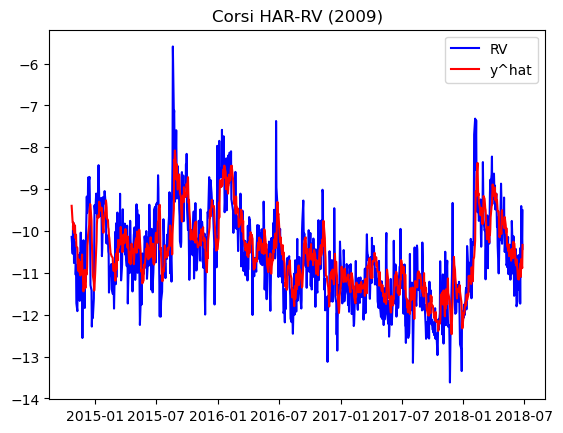

In [30]:
#The model compared to the target
sp500["Date"]=pd.to_datetime(sp500['Unnamed: 0'])
dates=sp500["Date"].iloc[split+22:].values[:len(y_test)]
plt.plot(dates,y_test,color='blue',label="RV")
plt.plot(dates,HAR_pred,color='red',label="y^hat")
plt.title("Corsi HAR-RV (2009)")
plt.legend()
plt.show()

Random Forest Model

In [31]:
#Random Forest Import
from sklearn.ensemble import RandomForestRegressor


In [33]:
# Initialize and Train The Model
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
# Make predictions
rf_pred = rf.predict(X_test)


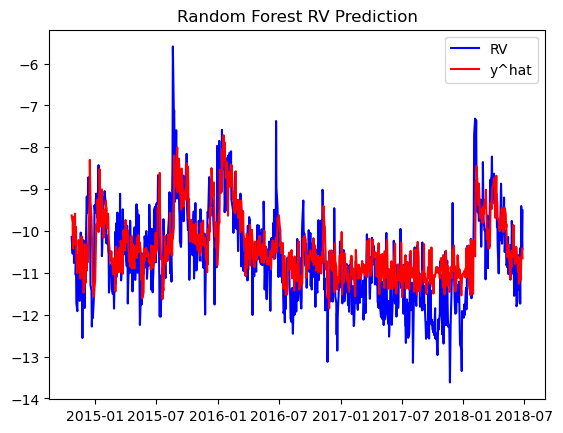

In [34]:
#Random Forest Model VS Naive Baseline 
sp500["Date"]=pd.to_datetime(sp500['Unnamed: 0'])
plt.plot(dates,y_test,color='blue',label="RV")
plt.plot(dates,rf_pred,color='red',label="y^hat")
plt.title("Random Forest RV Prediction")
plt.legend()
plt.show()

In [35]:
#Random Forest QLIKE 
qlike_rf=qlike_loss(y_test,rf_pred)
qlike_naive=qlike_loss(y_test_naive,naive_pred)

print(f"QLIKE Random Forest: {qlike_rf:.6f}")
print(f"QLIKE Naive: {qlike_naive:.6f}")
print(f"Improvement of Random Forest over Naive:{((qlike_naive-qlike_rf)/qlike_naive)*100:.2f}% ")

QLIKE Random Forest: 0.477593
QLIKE Naive: 0.292132
Improvement of Random Forest over Naive:-63.49% 


In [36]:
#Random Forest Mincer-Zarnowitz Regression
mincer_zarnowitz(rf_pred)

                            OLS Regression Results                            
Dep. Variable:                 actual   R-squared:                       0.435
Model:                            OLS   Adj. R-squared:                  0.435
Method:                 Least Squares   F-statistic:                     389.5
Date:                Sat, 25 Apr 2026   Prob (F-statistic):           1.40e-72
Time:                        14:52:40   Log-Likelihood:                -1123.2
No. Observations:                 923   AIC:                             2250.
Df Residuals:                     921   BIC:                             2260.
Df Model:                           1                                         
Covariance Type:                  HAC                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -0.7086      0.502     -1.411      0.1

In [37]:
#Random Forest Diebold-Mariano Test
diebold_mariano(rf_pred,'Random Forest')

DM Statistic: 5.1710
P-value: 0.0000
Conclusion: Naive significantly better


Neural Network Model

In [38]:
#Neural Network Imports 
import torch
from torch import nn


In [39]:
#The Neural Network Class for Predicting Realized Volatility
class RV_Prediction(nn.Module):
    def __init__ (self, input_size,hidden_size,output_size):
        super(RV_Prediction,self).__init__()
        self.fc1=nn.Linear(input_size,hidden_size)
        self.relu=nn.ReLU()
        self.fc2=nn.Linear(hidden_size,output_size)
    def forward(self,x):
        out=self.fc1(x)
        out=self.relu(out)
        out=self.fc2(out)
        return out





In [40]:
#Fitting the Neural Network  

#Scale Features 
scaler=StandardScaler()
scaler_y=StandardScaler()
X_train_scaled=scaler.fit_transform(X_train)
X_test_scaled=scaler.transform(X_test)
y_train_scaled=scaler_y.fit_transform(y_train.values.reshape(-1,1)).squeeze()
#Convert to tensors 
X_train_t=torch.tensor(X_train_scaled,dtype=torch.float32)
y_train_t=torch.tensor(y_train_scaled,dtype=torch.float32).unsqueeze(1)
X_test_t=torch.tensor(X_test_scaled,dtype=torch.float32)

#Instantiate the model
mlp_model=RV_Prediction(input_size=3,hidden_size=64,output_size=1)

#Loss and Optimizer
criterion=nn.MSELoss()
optimizer=torch.optim.Adam(mlp_model.parameters(),lr=1e-3)

#Training Loop
epochs=200
for epoch in range (epochs):
    mlp_model.train()
    optimizer.zero_grad()
    output=mlp_model(X_train_t)
    loss=criterion(output,y_train_t)
    loss.backward()
    optimizer.step()

#Predictions
mlp_model.eval()
with torch.no_grad():
    mlp_pred_raw=scaler_y.inverse_transform(mlp_model(X_test_t).detach().numpy()).squeeze()

mlp_pred=pd.Series(mlp_pred_raw,index=y_test.index)








In [41]:
#Neural Network QLIKE 
qlike_mlp=qlike_loss(y_test,mlp_pred)
qlike_naive=qlike_loss(y_test_naive,naive_pred)

print(f"QLIKE Neural Network: {qlike_mlp:.6f}")
print(f"QLIKE Naive: {qlike_naive:.6f}")
print(f"Improvement of Neural Network over Naive:{((qlike_naive-qlike_mlp)/qlike_naive)*100:.2f}% ")

QLIKE Neural Network: 0.389185
QLIKE Naive: 0.292132
Improvement of Neural Network over Naive:-33.22% 


In [42]:
#Mincer-Zarnowitz Regression 
mincer_zarnowitz(mlp_pred)

                            OLS Regression Results                            
Dep. Variable:                 actual   R-squared:                       0.539
Model:                            OLS   Adj. R-squared:                  0.539
Method:                 Least Squares   F-statistic:                     658.9
Date:                Sat, 25 Apr 2026   Prob (F-statistic):          4.87e-110
Time:                        14:53:23   Log-Likelihood:                -1029.5
No. Observations:                 923   AIC:                             2063.
Df Residuals:                     921   BIC:                             2073.
Df Model:                           1                                         
Covariance Type:                  HAC                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      0.3362      0.434      0.775      0.4

In [43]:
#Random Forest: Diebold-Mariano Test
diebold_mariano(mlp_pred,'MLP')

DM Statistic: 1.1950
P-value: 0.2321
Conclusion: No significant difference


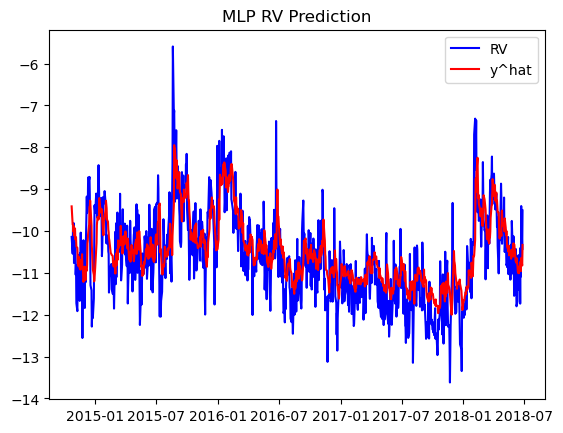

In [44]:
#MLP VS Naive Baseline 
#The model compared to the target
sp500["Date"]=pd.to_datetime(sp500['Unnamed: 0'])
plt.plot(dates,y_test,color='blue',label="RV")
plt.plot(dates,mlp_pred,color='red',label="y^hat")
plt.title("MLP RV Prediction")
plt.legend()
plt.show()

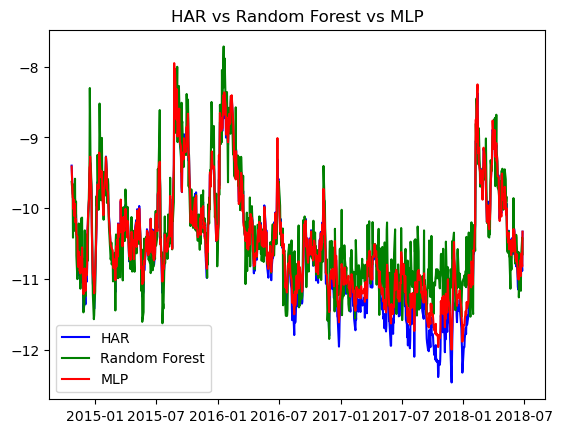

In [45]:
#HAR vs Random Forest vs MLP
#The model compared to the target
sp500["Date"]=pd.to_datetime(sp500['Unnamed: 0'])
dates=sp500["Date"].iloc[split+22:].values[:len(y_test)]
plt.plot(dates,HAR_pred,color='blue',label="HAR")
plt.plot(dates,rf_pred,color='green',label="Random Forest")
plt.plot(dates,mlp_pred,color='red',label="MLP")
plt.title("HAR vs Random Forest vs MLP")
plt.legend()
plt.show()

In [46]:
#Now for comparing the models themselves using the Diebols-Mariano Test
#Diebold-Mariano Test
#H0: HAR and naive have equal forecast accuracy 
#Negative DM stat= HAR has lower loss-HAR wins
def diebold_mariano_pairwise(predictions1:pd.Series,predictions2:pd.Series,model1:str,model2:str):
    e_model1=y_test_naive.values-predictions1[1:]
    e_model2=y_test_naive.values-predictions2[1:]

    #Loss Differntial 
    d=e_model1**2-e_model2**2   
    #DM statistic with HAC Variance
    T=len(d)
    d_mean=np.mean(d)
    d_var=np.var(d,ddof=1)
    #Newey-West adjustment for serial correlation 
    lags=5
    nw_var=d_var
    for k in range(1,lags+1):
        cov_k=np.mean((d[k:]-d_mean)*(d[:-k]-d_mean))
        nw_var+=2*(1-k/(lags+1))*cov_k

    dm_stat=d_mean/np.sqrt(nw_var/T)
    p_value=2*(1-stats.norm.cdf(abs(dm_stat)))

    print(f"DM Statistic: {dm_stat:.4f}")
    print(f"P-value: {p_value:.4f}")
   
    print(f"Conclusion: {model1} Significantly better" if dm_stat <-1.96 else f"{model2} significantly better" if dm_stat>1.96 else f"No significant difference")
    


In [47]:
diebold_mariano_pairwise(HAR_pred,rf_pred,"HAR","Random Forest")
print("")
diebold_mariano_pairwise(HAR_pred,mlp_pred,"HAR","MLP")
print("")
diebold_mariano_pairwise(mlp_pred,rf_pred,"MLP","Random Forest")

DM Statistic: -3.1721
P-value: 0.0015
Conclusion: HAR Significantly better

DM Statistic: -0.8328
P-value: 0.4049
No significant difference

DM Statistic: -3.3857
P-value: 0.0007
Conclusion: MLP Significantly better


In [48]:
summary = pd.DataFrame({
    "Model": ["Naive", "HAR-RV", "Random Forest", "MLP"],
    "QLIKE": [qlike_naive, qlike_har, qlike_rf, qlike_mlp]
}).set_index("Model").round(6)
print(summary)

                  QLIKE
Model                  
Naive          0.292132
HAR-RV         0.402441
Random Forest  0.477593
MLP            0.389185
